# Машинное обучение, ФКН ВШЭ

## Практическое задание 11. Метод опорных векторов и аппроксимация ядер

### Общая информация

Дата выдачи: 06.05.2026

Мягкий дедлайн: 23:59MSK 18.05.2026

Жесткий дедлайн: 23:59MSK 23.05.2026

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимальная оценка за работу (без учёта бонусов) — 10 баллов. Всего за работу с бонусами можно набрать 12.75 баллов.

Сдавать задание после указанного жёсткого срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Использование генеративных языковых моделей разрешено только в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):
- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего

Неэффективная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-11-random-features-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

### О задании

На занятиях мы подробно обсуждали метод опорных векторов (SVM). В базовой версии в нём нет чего-то особенного — мы всего лишь используем специальную функцию потерь, которая не требует устремлять отступы к бесконечности; ей достаточно, чтобы отступы были не меньше +1. Затем мы узнали, что SVM можно переписать в двойственном виде, который, позволяет заменить скалярные произведения объектов на ядра. Это будет соответствовать построению модели в новом пространстве более высокой размерности, координаты которого представляют собой нелинейные модификации исходных признаков.

Ядровой SVM, к сожалению, довольно затратен по памяти (нужно хранить матрицу Грама размера $d \times d$) и по времени (нужно решать задачу условной оптимизации с квадратичной функцией, а это не очень быстро). Мы обсуждали, что есть способы посчитать новые признаки $\tilde \varphi(x)$ на основе исходных так, что скалярные произведения этих новых $\langle \tilde \varphi(x), \tilde \varphi(z) \rangle$ приближают ядро $K(x, z)$.

Мы будем исследовать аппроксимации методом Random Fourier Features (RFF, также в литературе встречается название Random Kitchen Sinks) для гауссовых ядер. Будем использовать формулы, которые немного отличаются от того, что было на лекциях (мы добавим сдвиги внутрь тригонометрических функций и будем использовать только косинусы, потому что с нужным сдвигом косинус превратится в синус):
$$\tilde \varphi(x) = (
\cos (w_1^T x + b_1),
\dots,
\cos (w_n^T x + b_n)
),$$
где $w_j \sim \mathcal{N}(0, 1/\sigma^2)$, $b_j \sim U[-\pi, \pi]$.

На новых признаках $\tilde \varphi(x)$ мы будем строить любую линейную модель.

Можно считать, что это некоторая новая парадигма построения сложных моделей. Можно направленно искать сложные нелинейные закономерности в данных с помощью градиентного бустинга или нейронных сетей, а можно просто нагенерировать большое количество случайных нелинейных признаков и надеяться, что быстрая и простая модель (то есть линейная) сможет показать на них хорошее качество. В этом задании мы изучим, насколько работоспособна такая идея.

### Алгоритм

Вам потребуется реализовать следующий алгоритм:
1. Понизить размерность выборки до new_dim с помощью метода главных компонент.
2. Для полученной выборки оценить гиперпараметр $\sigma^2$ с помощью эвристики (рекомендуем считать медиану не по всем парам объектов, а по случайному подмножеству из где-то миллиона пар объектов): $$\sigma^2 = \text{median}_{i, j = 1, \dots, \ell, i \neq j} \left\{\sum_{k = 1}^{d} (x_{ik} - x_{jk})^2 \right\}$$
3. Сгенерировать n_features наборов весов $w_j$ и сдвигов $b_j$.
4. Сформировать n_features новых признаков по формулам, приведённым выше.
5. Обучить линейную модель (логистическую регрессию или SVM) на новых признаках.
6. Повторить преобразования (PCA, формирование новых признаков) к тестовой выборке и применить модель.

Тестировать алгоритм мы будем на данных Fashion MNIST. Ниже код для их загрузки и подготовки.

In [1]:
import numpy as np

# 1 Способ
import keras
from keras.datasets import fashion_mnist
(x_train_pics, y_train), (x_test_pics, y_test) = fashion_mnist.load_data()

# 2 Способ (если первый не работает)
# from sklearn.datasets import fetch_openml
# def load_fashion_mnist():
#     X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
#     X = X.reshape(-1, 28, 28).astype('uint8')
#     y = y.astype('int64')
#     x_train, x_test = X[:60000], X[60000:]
#     y_train, y_test = y[:60000], y[60000:]
#     return (x_train, y_train), (x_test, y_test)
# (x_train_pics, y_train), (x_test_pics, y_test) = load_fashion_mnist()




x_train = x_train_pics.reshape(y_train.shape[0], -1)
x_test = x_test_pics.reshape(y_test.shape[0], -1)

2026-05-18 19:37:17.152238: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779133037.873551      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779133038.118629      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779133040.047398      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779133040.047455      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779133040.047458      57 computation_placer.cc:177] computation placer alr

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


__Задание 0. (0.25 баллов)__

**Вопрос:** зачем в алгоритме нужен метод главных компонент? 

**Ответ:** мы используем PCA, поскольку, во-первых, метод позволяет снизить размерность признаков до какого угодно, что будет значительно ускорять наши вычисления при подсчетах сигмы, а также при получении признаков в новом пространстве. Во-вторых, само проектирование данных в новое пространство позволяет убрать малоинформативные признаки, а также случайный шум, который мог быть в признаках с маленькой дисперсией. Например, в наших картинках скорее всего не каждый пиксель будет полезен и возможно он будет даже смещать модель в сторону неверной классификации - PCA позволяет этого избежать. То есть PCA выделяет основные направления изменчивости данных, благодаря чему делает обучение более устойчивым

__Задание 1. (3 балла)__

Реализуйте алгоритм, описанный выше. Можете воспользоваться шаблоном класса в `homework_practice_08_rff.py` (допишите его и исправьте несостыковки в классе пайплайна) или написать свой интерфейс.

Ваша реализация должна поддерживать следующие опции:
1. Возможность задавать значения гиперпараметров new_dim (по умолчанию 50) и n_features (по умолчанию 1000).
2. Возможность включать или выключать предварительное понижение размерности с помощью метода главных компонент.
3. Возможность выбирать тип линейной модели (логистическая регрессия или SVM с линейным ядром).

Протестируйте на данных Fashion MNIST, сформированных кодом выше. Если на тесте у вас получилась доля верных ответов не ниже 0.84 с гиперпараметрами по умолчанию, то вы всё сделали правильно.

In [2]:
import sys

sys.path.append('/kaggle/input/datasets/shaykoaleksandr/home-work-11')

In [3]:
from homework_practice_11_rff import RFFPipeline, RandomFeatureCreator, FeatureCreatorPlaceholder

pipeline = RFFPipeline(n_features=1000, new_dim=50, feature_creator_class=RandomFeatureCreator)

In [4]:
from sklearn.metrics import accuracy_score
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

accuracy_score(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8591

__Задание 2. (2.5 балла)__

Сравните подход со случайными признаками с обучением SVM на исходных признаках. Попробуйте вариант с обычным (линейным) SVM и с ядровым SVM. Ядровой SVM может очень долго обучаться, поэтому можно делать любые разумные вещи для ускорения: брать подмножество объектов из обучающей выборки, например.

Сравните подход со случайными признаками с вариантом, в котором вы понижаете размерность с помощью PCA и обучите градиентный бустинг. Используйте одну из реализаций CatBoost/LightGBM/XGBoost.

Сделайте выводы — насколько идея со случайными признаками работает? Сравните как с точки зрения качества, так и с точки зрения скорости обучения и применения.

In [4]:
from sklearn.metrics import accuracy_score
import time
import pandas as pd

from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import train_test_split

In [7]:
# Your code here: (￣▽￣)/♫•*¨*•.¸¸♪
import time
import pandas as pd

from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import train_test_split

def evaluate_model(model, x_train, y_train, x_test, y_test, name):
    print(f'Training {name}')

    start_fit = time.perf_counter()
    model.fit(x_train, y_train)
    learn_time = time.perf_counter() - start_fit

    print(f'Predicting')

    start_predict = time.perf_counter()
    y_pred = model.predict(x_test)
    predict_time = time.perf_counter() - start_predict

    accuracy = accuracy_score(y_test, y_pred)

    print(f'{name}')
    print(f'Accuracy: {accuracy}')
    print(f'Learn time: {learn_time} sec')
    print(f'Predict time: {predict_time} sec')
    print()

    return {
        'model': name,
        'accuracy': accuracy,
        'learn_time_sec': learn_time,
        'predict_time_sec': predict_time
    }

In [6]:
linear_svm_pipeline = RFFPipeline(
    use_PCA=False,
    feature_creator_class=FeatureCreatorPlaceholder,
    classifier_class=LinearSVC
)

linear_svm_result = evaluate_model(
    linear_svm_pipeline,
    x_train,
    y_train,
    x_test,
    y_test,
    name='Linear SVM'
)

Training Linear SVM
Predicting
Linear SVM
Accuracy: 0.838
Learn time: 2640.388512939 sec
Predict time: 0.03224474499984353 sec



In [7]:
x_train_small, _, y_train_small, _ = train_test_split(
    x_train,
    y_train,
    train_size=5000,
    stratify=y_train,
    random_state=67
)

kernel_svm_pipeline = RFFPipeline(
    use_PCA=False,
    feature_creator_class=FeatureCreatorPlaceholder,
    classifier_class=SVC,
    classifier_params={
        'kernel': 'rbf'
    }
)

kernel_svm_result = evaluate_model(
    kernel_svm_pipeline,
    x_train_small,
    y_train_small,
    x_test,
    y_test,
    name='RBF SVM, train_size=5000'
)

Training RBF SVM, train_size=5000
Predicting
RBF SVM, train_size=5000
Accuracy: 0.8404
Learn time: 2.74458100999982 sec
Predict time: 21.677130028999727 sec



In [8]:
rff_result = evaluate_model(
    pipeline,
    x_train,
    y_train,
    x_test,
    y_test,
    name='RFF + Logistic Regression'
)

Training RFF + Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Predicting
RFF + Logistic Regression
Accuracy: 0.8592
Learn time: 34.10279387199989 sec
Predict time: 0.4744457130000228 sec



In [9]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

num_classes = len(np.unique(y_train))

boosting_pipeline = Pipeline([
    ('pca', PCA(n_components=50)),
    ('classifier', XGBClassifier(
        random_state=67
    ))
])

boosting_result = evaluate_model(
    boosting_pipeline,
    x_train,
    y_train,
    x_test,
    y_test,
    name='PCA + XGBoost'
)

Training PCA + XGBoost
Predicting
PCA + XGBoost
Accuracy: 0.8711
Learn time: 17.20209463900028 sec
Predict time: 0.22062446299969452 sec



In [10]:
results = pd.DataFrame([
    rff_result,
    linear_svm_result,
    kernel_svm_result,
    boosting_result
])

results

,model,accuracy,learn_time_sec,predict_time_sec
0,RFF + Logistic Regression,0.8592,34.102794,0.474446
1,Linear SVM,0.8380,2640.388513,0.032245
2,"RBF SVM, train_size=5000",0.8404,2.744581,21.677130
3,PCA + XGBoost,0.8711,17.202095,0.220624


Как мы в итоге убедились, модель со случайными признаками показывает довольно высокие результаты. Она обучилась на accuracy 0.8592, что выше, чем у линейного SVM на исходных признаках (0.8380) и выше, чем у ядрового SVM, обученного на подвыборке из 5000 объектов (0.8404). То есть случайные признаки помогают модели учитывать многообразие нелинейности структуры данных и хорошо приближает гауссовское ядро. 

По сравненю с линейным SVM, RFF оказался качественнее и намного быстрее в обучении (линейный обучался 2640 секунд, а RFF 34 секунды). Хотя конечно на этапе предсказания линейный SVM быстрее - но качество и скорость обучения конечно важнее.

С ядровым SVM есть другая проблема - он очень быстро обучился (за примерно 3 секунды), качество получилось не намного ниже, чем в RFF, однако предсказание было очень медленным, которое заняло 21 секунду. Это связано с тем, что ядровой SVM при предсказании должен сравнивать тестовые объекты с опорными векторами. Поэтому даже если обучение на маленькой подвыборке быстрое, применение модели может быть дорогим. Здесь RFF конечно побеждает в пользу предсказания.

Тем не менне, PCA + XGBoost и обучился всего за 17 секунд и дал наибольший accuracy 0.8711. Поэтому градиентный бустинг сильный конкурент RFF для классификации.

__Задание 3. (1.75 балла)__

Проведите эксперименты:
1. Помогает ли предварительное понижение размерности с помощью PCA?
2. Как зависит итоговое качество от n_features? Выходит ли оно на плато при росте n_features?
3. Важно ли, какую модель обучать — логистическую регрессию или SVM?

In [8]:
# Your code here: (￣▽￣)/♫•*¨*•.¸¸♪
from sklearn.linear_model import LogisticRegression
pca_results = []

rff_with_pca = RFFPipeline(
    n_features=1000,
    new_dim=50, 
    use_PCA=True, 
    feature_creator_class=RandomFeatureCreator, 
    classifier_class=LogisticRegression
)

pca_results.append(
    evaluate_model(
        rff_with_pca,
        x_train,
        y_train,
        x_test,
        y_test,
        name='RFF + LogisticRegression, with PCA'
    )
)


rff_without_pca = RFFPipeline(
    n_features=1000,
    new_dim=50,
    use_PCA=False,
    feature_creator_class=RandomFeatureCreator,
    classifier_class=LogisticRegression
)

pca_results.append(
    evaluate_model(
        rff_without_pca,
        x_train,
        y_train,
        x_test,
        y_test,
        name='RFF + LogisticRegression, without PCA'
    )
)

pca_results_df = pd.DataFrame(pca_results)
pca_results_df

Training RFF + LogisticRegression, with PCA


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Predicting
RFF + LogisticRegression, with PCA
Accuracy: 0.8572
Learn time: 32.12116395700002 sec
Predict time: 0.38126759499994023 sec

Training RFF + LogisticRegression, without PCA


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Predicting
RFF + LogisticRegression, without PCA
Accuracy: 0.8626
Learn time: 37.43608080000001 sec
Predict time: 0.5055758659999583 sec



,model,accuracy,learn_time_sec,predict_time_sec
0,"RFF + LogisticRegression, with PCA",0.8572,32.121164,0.381268
1,"RFF + LogisticRegression, without PCA",0.8626,37.436081,0.505576


В итоге мы видим, что PCA ускоряет обучение и предсказание, но при этом проигрывает в accuracy немного, что понятно, потому что модель без PCA вообще не теряет никакой информации, которую теряет PCA при понижении размерноси. То есть PCA нам все ускоряет, но не факт, что улучшает качество.

In [9]:
our_n_features = [100, 300, 500, 1000, 2000]

n_features_results = []

for n_features in our_n_features:
    model = RFFPipeline(
        n_features=n_features,
        new_dim=50,
        use_PCA=True,
        feature_creator_class=RandomFeatureCreator,
        classifier_class=LogisticRegression
    )

    result = evaluate_model(
        model,
        x_train,
        y_train,
        x_test,
        y_test,
        name=f'RFF + LogisticRegression, PCA, n_features={n_features}'
    )

    result['n_features'] = n_features
    n_features_results.append(result)

n_features_results_df = pd.DataFrame(n_features_results)
n_features_results_df

Training RFF + LogisticRegression, PCA, n_features=100


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Predicting
RFF + LogisticRegression, PCA, n_features=100
Accuracy: 0.8343
Learn time: 13.44319102899999 sec
Predict time: 0.06676210399996307 sec

Training RFF + LogisticRegression, PCA, n_features=300


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Predicting
RFF + LogisticRegression, PCA, n_features=300
Accuracy: 0.8488
Learn time: 16.26079542299999 sec
Predict time: 0.12491365800008225 sec

Training RFF + LogisticRegression, PCA, n_features=500


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Predicting
RFF + LogisticRegression, PCA, n_features=1000
Accuracy: 0.8575
Learn time: 28.4561180500001 sec
Predict time: 0.34529393699995126 sec

Training RFF + LogisticRegression, PCA, n_features=2000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Predicting
RFF + LogisticRegression, PCA, n_features=2000
Accuracy: 0.8591
Learn time: 46.86172935800016 sec
Predict time: 0.5630524130001504 sec



,model,accuracy,learn_time_sec,predict_time_sec,n_features
0,"RFF + LogisticRegression, PCA, n_features=100",0.8343,13.443191,0.066762,100
1,"RFF + LogisticRegression, PCA, n_features=300",0.8488,16.260795,0.124914,300
2,"RFF + LogisticRegression, PCA, n_features=500",0.8573,17.783663,0.191922,500
3,"RFF + LogisticRegression, PCA, n_features=1000",0.8575,28.456118,0.345294,1000
4,"RFF + LogisticRegression, PCA, n_features=2000",0.8591,46.861729,0.563052,2000


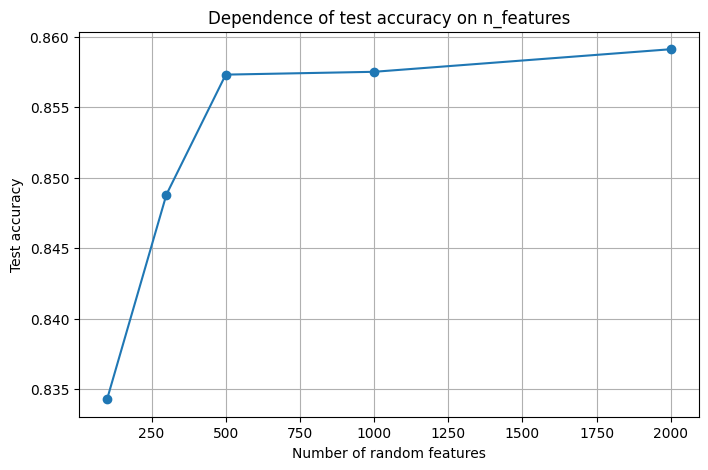

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    n_features_results_df['n_features'],
    n_features_results_df['accuracy'],
    marker='o'
)

plt.xlabel('Number of random features')
plt.ylabel('Test accuracy')
plt.title('Dependence of test accuracy on n_features')
plt.grid(True)

plt.show()

Как мы видим, сначала качество сильно растет при признаках от 100 до 500, поскольку чем больше случайных признаков, тем лучше приближение гауссовского ядра. Но после прирост маленький, то есть после примерно 500 признаков качество выходит на плато. В итоге время обучения прирастает, а качества не прирастает почти

In [11]:
classifier_results = []

logreg_result = pca_results_df[pca_results_df['model'] == 'RFF + LogisticRegression, with PCA'].iloc[0].to_dict()

logreg_result['model'] = 'RFF + LogisticRegression'

classifier_results.append(logreg_result)

rff_linear_svm = RFFPipeline(
    n_features=1000,
    new_dim=50,
    use_PCA=True,
    feature_creator_class=RandomFeatureCreator,
    classifier_class=LinearSVC
)

classifier_results.append(
    evaluate_model(
        rff_linear_svm,
        x_train,
        y_train,
        x_test,
        y_test,
        name='RFF + LinearSVC'
    )
)

classifier_results_df = pd.DataFrame(classifier_results)
classifier_results_df

Training RFF + LinearSVC
Predicting
RFF + LinearSVC
Accuracy: 0.8803
Learn time: 404.2276793059998 sec
Predict time: 0.3038940039998579 sec



,model,accuracy,learn_time_sec,predict_time_sec
0,RFF + LogisticRegression,0.8572,32.121164,0.381268
1,RFF + LinearSVC,0.8803,404.227679,0.303894


Как мы видим, в итоге важно какую в итоге модель выбирать, потому что LinearSVM после RFF дал намного лучшее качество 0.8803 по сравнению с RFF (0.8572). Тем не менее, время обучения конечно стало намного дольше. То есть тут смотря что нам важнее - качество или время обучения. 

In [12]:
all_experiments_df = pd.concat(
    [
        pca_results_df,
        n_features_results_df,
        classifier_results_df
    ],
    ignore_index=True
)

all_experiments_df

,model,accuracy,learn_time_sec,predict_time_sec,n_features
0,"RFF + LogisticRegression, with PCA",0.8572,32.121164,0.381268,NaN
1,"RFF + LogisticRegression, without PCA",0.8626,37.436081,0.505576,NaN
2,"RFF + LogisticRegression, PCA, n_features=100",0.8343,13.443191,0.066762,100.0
3,"RFF + LogisticRegression, PCA, n_features=300",0.8488,16.260795,0.124914,300.0
4,"RFF + LogisticRegression, PCA, n_features=500",0.8573,17.783663,0.191922,500.0
5,"RFF + LogisticRegression, PCA, n_features=1000",0.8575,28.456118,0.345294,1000.0
6,"RFF + LogisticRegression, PCA, n_features=2000",0.8591,46.861729,0.563052,2000.0
7,RFF + LogisticRegression,0.8572,32.121164,0.381268,NaN
8,RFF + LinearSVC,0.8803,404.227679,0.303894,NaN


__Бонус. (Максимум 1.75 балла)__

Как вы, должно быть, помните с курса МО-1, многие алгоритмы машинного обучения работают лучше, если признаки данных некоррелированы. Оказывается, что для RFF существует модификация, позволяющая получать ортогональные случайные признаки (Orthogonal Random Features, ORF). Об этом методе можно прочитать в [статье](https://proceedings.neurips.cc/paper/2016/file/53adaf494dc89ef7196d73636eb2451b-Paper.pdf). Реализуйте класс для вычисления ORF по аналогии с основным заданием. Обратите внимание, что ваш класс должен уметь работать со случаем n_features > new_dim (в статье есть замечание на этот счет), n_features=new_dim и n_features < new_dim также должны работать, убедитесь в этом. Проведите эксперименты, сравнивающие RFF и ORF, сделайте выводы.


__Бонус. (Максимум 1 балл)__

Существует большое количество работ, где идея RFF развивается, предлагаются её обобщения (которые, по сути, выливаются в другие преобразования признаков, не обязательно уже тригонометрические). Возьмите любую из таких работ, кратко опишите идею, имплементируйте её и сравните качество с ORF и RFF, которые вы запрограммировали выше.

Ссылки на статьи, где обсуждаются вариации RFF для разных ядер, можно найти в окрестности таблицы 1 в работе https://arxiv.org/pdf/1407.5599  

___ссылка на работу:___

___описание идеи:___

In [ ]:
# Пример

__Задание 4. (Максимум 2.5 балла)__

Реализуйте класс ядровой Ridge регрессии (Лекция 13, $\S 1.2$), для оптимизации используте градиентный спуск **[1 балл максимум]**, также добавьте возможность использовать аналитическую формулу **[1 балл максимум]**. Для градиентного спуска выпишите градиент ниже **[0.5 баллов максимум]**.
Подумайте о том, как в формулах правильно учесть свободный коэффициент.

Затем адаптируйте вашу реализацию RFF под задачу регрессии. Сравните вашу ядровую регрессию и RFF на синтетических данных.

Функция потерь:
$$
Q(w) = \frac{1}{2} ||\Phi \Phi^T w - y||^2 + \frac{\lambda}{2} w^T \Phi \Phi^T w \rightarrow \min_w,
$$
где $\Phi \Phi^T = K$, $K = (k(x_i, x_j))_{i, j = 1}^{\ell}$.

Предсказание:
$
y(x) = k(x)^T w,
$
где $k(x)$ — вектор функций ядра от пар объектов $(x, x_i)_{i=1}^{\ell}$.

___Выведите градиент:___

Пусть

$$
K = \Phi \Phi^T.
$$

Тогда функция потерь имеет вид:

$$
Q(w) = \frac{1}{2} \|Kw - y\|^2 + \frac{\lambda}{2} w^T K w.
$$

Обозначим ошибку:

$$
e = Kw - y.
$$

Тогда первый член функции потерь:

$$
\frac{1}{2} \|Kw - y\|^2 = \frac{1}{2} e^T e.
$$

Его градиент по $w$:

$$
\nabla_w \frac{1}{2} \|Kw - y\|^2 = K^T(Kw - y).
$$

Так как матрица ядра $K$ симметрична, то $K^T = K$:

$$
\nabla_w \frac{1}{2} \|Kw - y\|^2 = K(Kw - y).
$$

Теперь найдём градиент регуляризатора:

$$
\nabla_w \frac{\lambda}{2} w^T K w = \lambda K w,
$$

поскольку $K$ симметрична.

Итоговый градиент:

$$
\nabla_w Q(w) = K(Kw - y) + \lambda K w.
$$

Или эквивалентно:

$$
\nabla_w Q(w) = K(Kw - y + \lambda w).
$$

Если используется свободный коэффициент $b$, то предсказания на обучающей выборке имеют вид:

$$
\hat y = Kw + b\mathbf{1}.
$$

Тогда функция потерь:

$$
Q(w, b) = \frac{1}{2} \|Kw + b\mathbf{1} - y\|^2 + \frac{\lambda}{2} w^T K w.
$$

Градиенты:

$$
\nabla_w Q(w, b) = K(Kw + b\mathbf{1} - y) + \lambda Kw.
$$

$$
\nabla_b Q(w, b) = \mathbf{1}^T(Kw + b\mathbf{1} - y).
$$

Вы можете изменять представленный шаблон в файле `homework_practice_11_kernel_regression.py` по своему усмотрению.

In [14]:
import sys

sys.path.append('/kaggle/input/datasets/shaykoaleksandr/homework-11-reg')

In [15]:
from homework_practice_11_kernel_regression import KernelRidgeRegression

Не хочу уже менять файл, поэтому добавлю изменения здесь

In [16]:
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.linear_model import Ridge
from typing import Callable
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import numpy as np


class FeatureCreatorPlaceholder(BaseEstimator, TransformerMixin):
    def __init__(self, n_features, new_dim, func: Callable = np.cos):
        self.n_features = n_features
        self.new_dim = new_dim
        self.w = None
        self.b = None
        self.func = func

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return X


class RandomFeatureCreator(FeatureCreatorPlaceholder):
    def fit(self, X, y=None):
        X = X.astype(np.float64)
        n_objects = X.shape[0]
        dim = X.shape[1]

        n_pairs = 1_000_000

        i = np.random.randint(0, n_objects, size=n_pairs)
        j = np.random.randint(0, n_objects, size=n_pairs)

        mask = i != j
        i = i[mask]
        j = j[mask]

        distances = np.sum((X[i] - X[j]) ** 2, axis=1)
        sigma_sqr = np.median(distances)

        self.w = np.random.normal(
            loc=0,
            scale=1 / np.sqrt(sigma_sqr),
            size=(dim, self.n_features)
        )

        self.b = np.random.uniform(
            low=-np.pi,
            high=np.pi,
            size=self.n_features
        )

        return self

    def transform(self, X, y=None):
        X = X.astype(np.float64)
        return self.func(X @ self.w + self.b)


class OrthogonalRandomFeatureCreator(RandomFeatureCreator):
    def fit(self, X, y=None):
        raise NotImplementedError


class RFFPipeline(BaseEstimator):
    """
    Пайплайн, делающий последовательно три шага:
        1. Применение PCA
        2. Применение RFF
        3. Применение классификатора
    """
    def __init__(
            self,
            n_features: int = 1000,
            new_dim: int = 50,
            use_PCA: bool = True,
            feature_creator_class=FeatureCreatorPlaceholder,
            classifier_class=LogisticRegression,
            classifier_params=None,
            func=np.cos,
    ):
        """
        :param n_features: Количество признаков, генерируемых RFF
        :param new_dim: Количество признаков, до которых сжимает PCA
        :param use_PCA: Использовать ли PCA
        :param feature_creator_class: Класс, создающий признаки, по умолчанию заглушка
        :param classifier_class: Класс классификатора
        :param classifier_params: Параметры, которыми инициализируется классификатор
        :param func: Функция, которую получает feature_creator при инициализации.
                     Если не хотите, можете не использовать этот параметр.
        """
        self.n_features = n_features
        self.new_dim = new_dim
        self.use_PCA = use_PCA
        if classifier_params is None:
            classifier_params = {}
        self.classifier = classifier_class(**classifier_params)
        self.feature_creator = feature_creator_class(
            n_features=self.n_features, new_dim=self.new_dim, func=func
        )
        self.pipeline = None

    def fit(self, X, y):
        if not self.use_PCA:
            self.new_dim = X.shape[1]
            self.feature_creator.new_dim = self.new_dim

        pipeline_steps: list[tuple] = []

        if self.use_PCA:
            pipeline_steps.append(('pca', PCA(n_components=self.new_dim)))

        pipeline_steps.append(('feature_creator', self.feature_creator))

        pipeline_steps.append(('classifier', self.classifier))

        self.pipeline = Pipeline(pipeline_steps).fit(X, y)
        return self

    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

    def predict(self, X):
        return self.pipeline.predict(X)


class RandomFeatureCreatorRegression(RandomFeatureCreator):

    def transform(self, X, y=None):
        X = X.astype(np.float64)
        return self.func(X @ self.w + self.b)


class RFFRegressionPipeline(BaseEstimator, RegressorMixin):

    def __init__(
        self,
        n_features: int = 1000,
        new_dim: int = 50,
        use_PCA: bool = True,
        feature_creator_class=RandomFeatureCreatorRegression,
        regressor_class=Ridge,
        regressor_params=None,
        func=np.cos,
    ):
        self.n_features = n_features
        self.new_dim = new_dim
        self.use_PCA = use_PCA

        if regressor_params is None:
            regressor_params = {}

        self.regressor = regressor_class(**regressor_params)

        self.feature_creator = feature_creator_class(
            n_features=self.n_features,
            new_dim=self.new_dim,
            func=func,
        )

        self.pipeline = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).ravel()

        if not self.use_PCA:
            self.new_dim = X.shape[1]
            self.feature_creator.new_dim = self.new_dim

        pipeline_steps = []

        if self.use_PCA:
            pipeline_steps.append(("pca", PCA(n_components=self.new_dim)))

        pipeline_steps.append(("feature_creator", self.feature_creator))
        pipeline_steps.append(("regressor", self.regressor))

        self.pipeline = Pipeline(pipeline_steps)
        self.pipeline.fit(X, y)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        return self.pipeline.predict(X)

In [17]:
np.random.seed(67)

X = np.linspace(-5, 5, 500).reshape(-1, 1)

y = (
    np.sin(X[:, 0])
    + 0.5 * np.cos(3 * X[:, 0])
    + 0.2 * np.random.randn(X.shape[0])
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=67
)

In [18]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

from homework_practice_11_kernel_regression import KernelRidgeRegression

start = time.time()

krr = KernelRidgeRegression(
    regularization=0.01,
    kernel_scale=1.0,
    fit_intercept=True
)

krr.fit_closed_form(X_train, y_train)

krr_time = time.time() - start
krr_pred = krr.predict(X_test)
krr_mse = mean_squared_error(y_test, krr_pred)

start = time.time()

rff = RFFPipeline(
    n_features=1000,
    new_dim=1,
    use_PCA=False,
    feature_creator_class=RandomFeatureCreator,
    classifier_class=Ridge,
    classifier_params={'alpha': 0.01}
)

rff.fit(X_train, y_train)

rff_time = time.time() - start
rff_pred = rff.predict(X_test)
rff_mse = mean_squared_error(y_test, rff_pred)


results = pd.DataFrame({
    'model': ['Kernel Ridge', 'RFF + Ridge'],
    'MSE': [krr_mse, rff_mse],
    'fit_time': [krr_time, rff_time]
})

results

,model,MSE,fit_time
0,Kernel Ridge,0.044991,0.005883
1,RFF + Ridge,0.127767,0.187810


Как мы видим, на этих синтетических данных ядровая Ridge-регрессия лучше, так как и качество лучше: MSE = 0.045 против 0.128 и обучение быстрее: 0.006 сек против 0.188 сек.